# Hessian-Based Filtering — Systematic Parameter Sweep

This notebook provides a systematic parameter sweep of Hessian-based filtering
(Frangi vesselness) for microscopy image analysis. Designed for reproducible exploration of
filter parameters across sigma, beta, c, thresholds, and channels.

---
## Section 1: Setup & Data Loading

In [3]:
%matplotlib inline

import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter, distance_transform_edt, label
from skimage.filters import threshold_otsu
from tqdm.auto import tqdm

from data_utils.load_data import load_full_volume

print('All imports successful.')

All imports successful.


In [4]:
# --- Data path ---
image_input = '/run/media/anokhver/Data/Veronika/ctu/Microscopy/Microscopy/20251030/2_3_PSYHARMIN_2_Multichannel Z-Stack_20251030_67.vsi'

# Load the full volume: shape (C, Z, Y, X)
data = load_full_volume(image_input)
print(f'Volume shape: {data.shape}')


SLF4J: No SLF4J providers were found.
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See https://www.slf4j.org/codes.html#noProviders for further details.


Physical pixel sizes: PhysicalPixelSizes(Z=None, Y=0.10685428060522417, X=0.10685428060522417)
Dimensions: <Dimensions [T: 1, C: 3, Z: 31, Y: 2304, X: 2304]>
Shape: (1, 3, 31, 2304, 2304)
Loaded shape: (3, 31, 2304, 2304) (C, Z, Y, X)
Volume shape: (3, 31, 2304, 2304)


In [5]:
# Select a single z-slice for 2D analysis
Z_SLICE = 20
data_z_sliced = data[:, Z_SLICE, :, :]
print(f'Z-slice shape: {data_z_sliced.shape}  (C, Y, X)')

Z-slice shape: (3, 2304, 2304)  (C, Y, X)


In [6]:
# --- Visualization helpers ---

def _black_to(rgb):
    """Create a colormap that goes from black to the given RGB color."""
    return LinearSegmentedColormap.from_list("", [(0, 0, 0), rgb])

# Default channel colormaps: black-to-red, black-to-green, black-to-blue
DEFAULT_CHANNEL_CMAPS = [_black_to((1, 0, 0)), _black_to((0, 1, 0)), _black_to((0, 0, 1))]


def show_imgs(images, titles=None, cmap="viridis", figsize=None,
              max_cols=3, split_channels=False, channel_cmaps=None):
    """
    Display one or more images in a grid.

    Args:
        images:          Single image (2D/3D array) or list of images.
        titles:          Optional list of titles, one per image.
        cmap:            Colormap for single-channel images (default: "viridis").
        figsize:         Figure size; auto-scaled from grid if None.
        max_cols:        Max columns in the grid.
        split_channels:  If True, display each channel of a (C,H,W) image
                         as a separate panel with its own colormap.
        channel_cmaps:   List of colormaps for split channels.
    """
    # --- Normalize input to a list of arrays ---
    if isinstance(images, np.ndarray) and images.ndim in (2, 3):
        images = [images]
    else:
        images = list(images)
    if not images:
        raise ValueError("images must contain at least one item")

    if channel_cmaps is None:
        channel_cmaps = DEFAULT_CHANNEL_CMAPS

    # --- Optionally split (C,H,W) images into per-channel panels ---
    per_image_cmaps = None
    if split_channels:
        split_imgs, split_titles, split_cmaps = [], [], []
        for idx, img in enumerate(images):
            img = np.asarray(img)
            base = titles[idx] if titles and idx < len(titles) else None
            if img.ndim == 3:                          # (C, H, W)
                for c in range(img.shape[0]):
                    split_imgs.append(img[c])
                    split_titles.append(f"{base} - ch{c}" if base else None)
                    split_cmaps.append(channel_cmaps[c % len(channel_cmaps)])
            else:                                      # (H, W) — no split needed
                split_imgs.append(img)
                split_titles.append(base)
                split_cmaps.append(cmap)
        images, titles, per_image_cmaps = split_imgs, split_titles, split_cmaps

    # --- Grid layout ---
    n = len(images)
    cols = min(max_cols, n)
    rows = math.ceil(n / cols)
    if figsize is None:
        figsize = (cols * 4, rows * 4)

    fig, axs = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axs = axs.ravel()

    for i, ax in enumerate(axs):
        if i < n:
            img = np.asarray(images[i])

            # (C,H,W) -> (H,W,C) for matplotlib; detect if it's RGB/RGBA
            is_color = False
            if img.ndim == 3:
                img = np.moveaxis(img, 0, -1)
                is_color = img.shape[-1] in (3, 4)

            # Color images need no colormap; single-channel ones do
            this_cmap = None if is_color else (per_image_cmaps[i] if per_image_cmaps else cmap)
            ax.imshow(img, cmap=this_cmap, vmin=0, vmax=np.percentile(img, 99.5))

            if titles and i < len(titles) and titles[i]:
                ax.set_title(titles[i])
        ax.axis("off")

    plt.tight_layout()
    return fig, axs[:n]

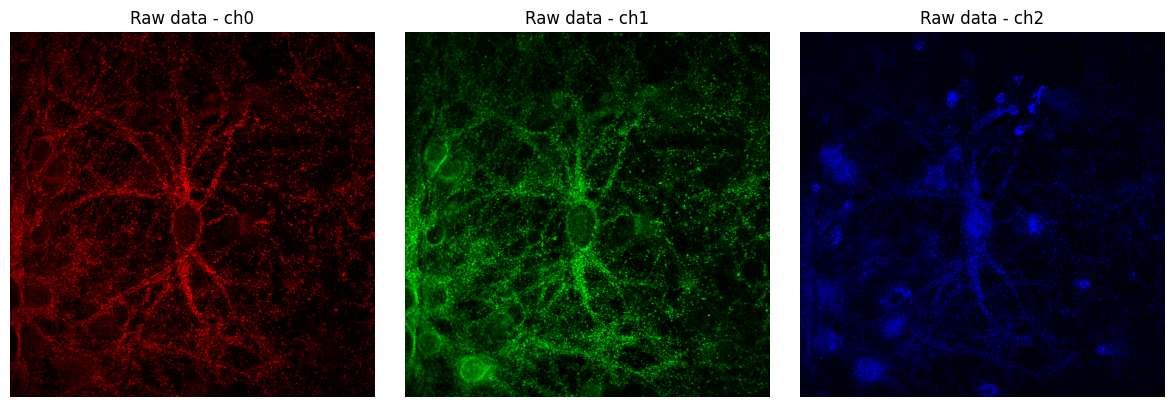

In [7]:
# Display the raw channels
show_imgs(data_z_sliced, split_channels=True, titles=['Raw data'])
plt.show()

---
## Section 2: Parameter Definition

In [14]:
# ── Parameter grids ──────────────────────────────────────────────────────────

sigma_values = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]
# sigma_values = [2.0, 2.5, 3.0, 3.2, 3.5, 4.0]


beta_values = [0.1, 0.3, 0.5, 0.7, 1.0]

c_values_basic = [5, 10, 15, 50, 100, 500]          # for basic Frangi
c_values_adaptive = [1e4, 1e5, 1e6, 2e6, 1e7]       # for adaptive pipeline

percentile_thresholds = [80, 85, 90, 95, 97]
soma_percentiles = [90, 93, 95, 97, 99]
channels = [2]

# Multi-scale sigma combinations
sigma_combinations = [
    [0.1, 0.3],
    [0.1, 0.5, 1.0],
    [0.2, 0.5, 0.7, 1.0],
    [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0],
]

print('Parameter grids defined.')
print(f'  sigma_values       : {sigma_values}')
print(f'  beta_values        : {beta_values}')
print(f'  c_values_basic     : {c_values_basic}')
print(f'  c_values_adaptive  : {c_values_adaptive}')
print(f'  percentile_thresholds : {percentile_thresholds}')
print(f'  soma_percentiles   : {soma_percentiles}')
print(f'  channels           : {channels}')
print(f'  sigma_combinations : {sigma_combinations}')

Parameter grids defined.
  sigma_values       : [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]
  beta_values        : [0.1, 0.3, 0.5, 0.7, 1.0]
  c_values_basic     : [5, 10, 15, 50, 100, 500]
  c_values_adaptive  : [10000.0, 100000.0, 1000000.0, 2000000.0, 10000000.0]
  percentile_thresholds : [80, 85, 90, 95, 97]
  soma_percentiles   : [90, 93, 95, 97, 99]
  channels           : [2]
  sigma_combinations : [[0.1, 0.3], [0.1, 0.5, 1.0], [0.2, 0.5, 0.7, 1.0], [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]]


In [15]:
def generate_param_grid(**kwargs):
    """
    Generate all combinations of the given keyword arguments using
    itertools.product.

    Parameters:
        **kwargs: Each keyword is a parameter name, each value is an iterable
                  of parameter values to sweep.

    Returns:
        list[dict]: A list of dictionaries, one per combination, with the
                    parameter names as keys.

    Example:
        >>> generate_param_grid(sigma=[0.5, 1.0], beta=[0.3, 0.5])
        [{'sigma': 0.5, 'beta': 0.3},
         {'sigma': 0.5, 'beta': 0.5},
         {'sigma': 1.0, 'beta': 0.3},
         {'sigma': 1.0, 'beta': 0.5}]
    """
    keys = list(kwargs.keys())
    vals = list(kwargs.values())
    return [dict(zip(keys, combo)) for combo in itertools.product(*vals)]


# Quick sanity check
test_grid = generate_param_grid(sigma=[0.5, 1.0], beta=[0.3, 0.5])
print(f'Test grid ({len(test_grid)} combinations):')
for g in test_grid:
    print(f'  {g}')

Test grid (4 combinations):
  {'sigma': 0.5, 'beta': 0.3}
  {'sigma': 0.5, 'beta': 0.5}
  {'sigma': 1.0, 'beta': 0.3}
  {'sigma': 1.0, 'beta': 0.5}


---
## Section 3: Parameterized Filter Functions

In [16]:
def compute_hessian_2d(image, sigma):
    """
    Compute 2D Hessian matrix eigenvalues.

    For a 2D image, the Hessian is:
        H = [[Ixx, Ixy],
             [Iyx, Iyy]]

    Eigenvalues are computed analytically for the 2x2 symmetric matrix:
        lambda = (trace ± sqrt(trace² - 4*det)) / 2

    Parameters:
        image (np.ndarray): 2D input image.
        sigma (float):      Gaussian scale for derivative computation.

    Returns:
        lambda1 (np.ndarray): Eigenvalue with smaller absolute value.
        lambda2 (np.ndarray): Eigenvalue with larger absolute value.
                              Sorted so |lambda1| <= |lambda2|.
    """
    #TODO check if I need to presmooth the image ???
    smoothed = image

    # Compute second derivatives
    Ixx = gaussian_filter(smoothed, sigma=sigma, order=[2, 0])
    Ixy = gaussian_filter(smoothed, sigma=sigma, order=[1, 1])
    Iyy = gaussian_filter(smoothed, sigma=sigma, order=[0, 2])

    # Analytical eigenvalue formula for 2x2 symmetric matrix
    trace = Ixx + Iyy
    det = Ixx * Iyy - Ixy * Ixy
    discriminant = np.sqrt(np.maximum(trace * trace - 4 * det, 0))

    lambda1 = (trace - discriminant) / 2
    lambda2 = (trace + discriminant) / 2

    # Sort by absolute value
    lambda1, lambda2 = (np.minimum(np.abs(lambda1), np.abs(lambda2)),
                        np.maximum(np.abs(lambda1), np.abs(lambda2)))

    return lambda1, lambda2

In [17]:
def frangi_filter_2d(lambda1, lambda2, beta=0.5, c=15):
    """
    Frangi vesselness filter for 2D images.

    Based on: "Multiscale vessel enhancement filtering" (MICCAI 1998).

    Parameters:
        lambda1 (np.ndarray): Smaller eigenvalue (by absolute value).
        lambda2 (np.ndarray): Larger eigenvalue (by absolute value).
        beta (float):         Controls sensitivity to the blobness measure R_b.
                              Default: 0.5.
        c (float):            Controls sensitivity to the second-order
                              structureness S. Default: 15.

    Returns:
        response (np.ndarray): Frangi vesselness response image.
    """
    # Avoid division by zero
    lambda2_safe = np.where(np.abs(lambda2) < 1e-10, 1e-10, lambda2)

    R_b = lambda1 / lambda2_safe
    S = np.sqrt(lambda1**2 + lambda2**2)

    response = np.zeros_like(lambda1)

    mask = lambda2 > 0

    response[mask] = (np.exp(-R_b[mask]**2 / (2 * beta**2)) *
                      (1 - np.exp(-S[mask]**2 / (2 * c**2))))

    return response

In [18]:
def multiscale_frangi_2d(image, sigmas, beta=0.5, c_mode='proportional',
                         c_value=10):
    """
    Multi-scale Frangi filtering.

    Runs Frangi at multiple Gaussian scales and takes the maximum response
    across scales for each pixel.

    Parameters:
        image (np.ndarray):  2D input image.
        sigmas (list):       List of sigma values for the Gaussian scales.
        beta (float):        Frangi beta. Default: 0.5.
        c_mode (str):        How to compute c for each sigma.
                             'proportional' -> c = c_value * sigma
                             'fixed'        -> c = c_value
        c_value (float):     Base value for c computation. Default: 10.

    Returns:
        multiscale_response (np.ndarray): Maximum response across all scales.
        responses (list):                  Individual response per scale.
    """
    responses = []

    for sigma in sigmas:
        lambda1, lambda2 = compute_hessian_2d(image, sigma)

        if c_mode == 'proportional':
            c = c_value * sigma
        else:  # 'fixed'
            c = c_value

        response = frangi_filter_2d(lambda1, lambda2, beta, c)
        responses.append(response)

    multiscale_response = np.maximum.reduce(responses)

    return multiscale_response, responses

In [19]:
def hessian_eigenvalues_2d(image, sigma):
    """
    Compute 2D Hessian eigenvalues at a given sigma with Lindeberg
    scale normalization (sigma^2).

    Unlike compute_hessian_2d(), this returns *signed* eigenvalues
    ordered by value (not absolute value).

    Parameters:
        image (np.ndarray): 2D input image.
        sigma (float):      Gaussian scale.

    Returns:
        lam1 (np.ndarray): Smaller signed eigenvalue.
        lam2 (np.ndarray): Larger signed eigenvalue.
    """
    s2 = sigma ** 2
    Ixx = gaussian_filter(image, sigma=sigma, order=[2, 0]) * s2
    Ixy = gaussian_filter(image, sigma=sigma, order=[1, 1]) * s2
    Iyy = gaussian_filter(image, sigma=sigma, order=[0, 2]) * s2

    trace = Ixx + Iyy
    det = Ixx * Iyy - Ixy ** 2
    discriminant = np.sqrt(np.maximum(trace ** 2 - 4 * det, 0))

    lam1 = (trace - discriminant) / 2  # smaller
    lam2 = (trace + discriminant) / 2  # larger
    return lam1, lam2

In [20]:
def frangi_vesselness_2d(lam1, lam2, beta=0.5, c=2e6):
    """
    2D Frangi vesselness response from signed Hessian eigenvalues.

    For bright tubular structures on a dark background the larger-magnitude
    eigenvalue is negative (concave across the tube).

    Parameters:
        lam1 (np.ndarray): Smaller signed eigenvalue.
        lam2 (np.ndarray): Larger signed eigenvalue.
        beta (float):      Blob-suppression weight. Default: 0.5.
        c (float):         Background-suppression weight. Default: 2e6.

    Returns:
        v (np.ndarray): Frangi vesselness response.
    """
    abs1, abs2 = np.abs(lam1), np.abs(lam2)
    sorted_small = np.minimum(abs1, abs2)  # |lambda_1|
    sorted_large = np.maximum(abs1, abs2)  # |lambda_2|

    large_safe = np.where(sorted_large < 1e-10, 1e-10, sorted_large)
    R_b = sorted_small / large_safe
    S = np.sqrt(sorted_small ** 2 + sorted_large ** 2)

    v = (np.exp(-R_b ** 2 / (2 * beta ** 2)) *
         (1 - np.exp(-S ** 2 / (2 * c ** 2))))

    # Zero out where the signed larger-magnitude eigenvalue is positive
    signed_large = np.where(abs2 >= abs1, lam2, lam1)
    v[signed_large > 0] = 0

    return v

In [21]:
def compute_adaptive_sigma_map(image, fg_threshold=None):
    """
    Binarize the image, compute the Euclidean Distance Transform, and derive
    a per-pixel Gaussian sigma from the DT (DDeep3M+ adaptive window).

    Paper formulas:
        DN = normalize DT to [1, 256]
        R  = log2(DN)   -> window radius in [0, 8]
        sigma = R       (clamped to [1, 8])

    Parameters:
        image (np.ndarray):   2D input image.
        fg_threshold (float): Foreground threshold. If None, Otsu is used.

    Returns:
        fg_mask (np.ndarray):   Binary foreground mask.
        dt (np.ndarray):        Raw distance transform.
        sigma_map (np.ndarray): Per-pixel sigma (float, range [1, 8]).
    """
    if fg_threshold is None:
        fg_threshold = threshold_otsu(image)
    fg_mask = image > fg_threshold

    dt = distance_transform_edt(fg_mask)

    # Normalize DT to [1, 256]
    dt_max = dt.max()
    dn = (dt / dt_max * 255 + 1) if dt_max > 0 else np.ones_like(dt)

    # Adaptive radius: R = log2(DN), clamped to [1, 8]
    sigma_map = np.clip(np.log2(np.clip(dn, 1, 256)), 1, 8)

    return fg_mask, dt, sigma_map

In [22]:
def fill_soma_holes(response, dt, percentile=95):
    """
    Fill soma holes in the Frangi response.

    Frangi tends to turn round soma into rings. This function detects soma
    centers via high Distance Transform values and sets their response to the
    maximum observed response.

    Parameters:
        response (np.ndarray):  Frangi response image (modified in-place).
        dt (np.ndarray):        Distance transform.
        percentile (float):     DT percentile above which pixels are soma.
                                Default: 95.

    Returns:
        response (np.ndarray): Modified response with soma holes filled.
    """
    if not np.any(dt > 0):
        return response
    threshold = np.percentile(dt[dt > 0], percentile)
    soma_mask = dt > threshold
    response[soma_mask] = response.max()
    return response

In [23]:
def adaptive_frangi_ddeep3m(image, fg_threshold=None, beta=0.8, c=2e6,
                            soma_percentile=95):
    """
    DDeep3M+ adaptive enhancement filter (2D adaptation).

    Pipeline:
        1. Binarize -> Distance Transform -> per-pixel sigma map
        2. Discretize sigmas to integers (1..8), compute Hessian per scale
        3. Frangi vesselness per scale, assign each pixel its scale's response
        4. Fill soma holes using high-DT regions

    Parameters:
        image (np.ndarray):       2D single-channel array.
        fg_threshold (float):     Foreground threshold (None = Otsu).
        beta (float):             Frangi blob-suppression. Default: 0.8.
        c (float):                Frangi background-suppression. Default: 2e6.
        soma_percentile (float):  DT percentile above which pixels are soma.
                                  Default: 95.

    Returns:
        response (np.ndarray):   Enhanced response image.
        fg_mask (np.ndarray):    Binary foreground mask.
        sigma_map (np.ndarray):  Per-pixel adaptive sigma.
    """
    image = image.astype(np.float64)

    # Adaptive sigma from Distance Transform
    fg_mask, dt, sigma_map = compute_adaptive_sigma_map(image, fg_threshold)

    # Discretize sigma -> integer scales
    sigma_discrete = np.round(sigma_map).astype(int)
    unique_sigmas = np.unique(sigma_discrete)

    response = np.zeros_like(image)

    for s in unique_sigmas:
        scale_mask = sigma_discrete == s

        lam1, lam2 = hessian_eigenvalues_2d(image, float(s))
        v = frangi_vesselness_2d(lam1, lam2, beta, c)

        response[scale_mask] = v[scale_mask]

    # Soma hole-filling
    response = fill_soma_holes(response, dt, soma_percentile)

    return response, fg_mask, sigma_map


print('All filter functions defined.')

All filter functions defined.


In [24]:
def show_frangi_mask(original, frangi_response, percentile=90, alpha=0.4):
    """
    Threshold Frangi response into a binary mask and overlay on original.

    Parameters:
        original (np.ndarray):       2D grayscale image.
        frangi_response (np.ndarray): Frangi filter output.
        percentile (float):          Top N% of response kept. Default: 90.
        alpha (float):               Overlay transparency. Default: 0.4.

    Returns:
        fig:  Matplotlib figure.
        mask: Binary mask.
    """
    nonzero = frangi_response[frangi_response > 0]
    if len(nonzero) == 0:
        threshold = 0
    else:
        threshold = np.percentile(nonzero, percentile)
    mask = frangi_response > threshold

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(original, cmap="gray", vmin=0,
                  vmax=np.percentile(original, 99.5))
    axs[0].set_title("Original")

    axs[1].imshow(mask, cmap="gray")
    axs[1].set_title(f"Mask (top {100 - percentile:.0f}%)")

    axs[2].imshow(original, cmap="gray", vmin=0,
                  vmax=np.percentile(original, 99.5))
    axs[2].imshow(mask, cmap=_black_to((1, 0, 0)), alpha=alpha, vmin=0, vmax=1)
    axs[2].set_title("Overlay")

    for ax in axs:
        ax.axis("off")
    plt.tight_layout()
    return fig, mask

---
## Section 4: Quantitative Metrics

In [25]:
def compute_metrics(response, original_image):
    """
    Compute quantitative metrics for a filter response.

    Parameters:
        response (np.ndarray):       Filter response image.
        original_image (np.ndarray): Original input image.

    Returns:
        dict with keys:
            mean_response   – Mean of non-zero response values.
            coverage        – Fraction of pixels with response > 0.
            contrast_ratio  – Ratio of mean foreground response to overall mean.
            snr             – Signal-to-noise ratio of the response.
            sparsity        – 1 - coverage (how selective the filter is).
            dynamic_range   – max / min of non-zero response values.
    """
    nonzero = response[response > 0]
    total_pixels = response.size

    if len(nonzero) == 0:
        return {
            'mean_response': 0.0,
            'coverage': 0.0,
            'contrast_ratio': 0.0,
            'snr': 0.0,
            'sparsity': 1.0,
            'dynamic_range': 0.0,
        }

    mean_fg = float(np.mean(nonzero))
    mean_all = float(np.mean(response))
    coverage = float(len(nonzero) / total_pixels)

    # SNR: mean / std of non-zero response
    std_fg = float(np.std(nonzero))
    snr = mean_fg / std_fg if std_fg > 0 else 0.0

    # Contrast ratio
    contrast_ratio = mean_fg / mean_all if mean_all > 0 else 0.0

    # Dynamic range
    min_nz = float(np.min(nonzero))
    max_nz = float(np.max(nonzero))
    dynamic_range = max_nz / min_nz if min_nz > 0 else 0.0

    return {
        'mean_response': mean_fg,
        'coverage': coverage,
        'contrast_ratio': contrast_ratio,
        'snr': snr,
        'sparsity': 1.0 - coverage,
        'dynamic_range': dynamic_range,
    }

In [26]:
def compute_mask_metrics(mask, response):
    """
    Compute metrics for a binary mask derived from a filter response.

    Parameters:
        mask (np.ndarray):     Binary mask (bool or 0/1).
        response (np.ndarray): Filter response from which the mask was derived.

    Returns:
        dict with keys:
            mask_coverage        – Fraction of image covered by mask.
            mask_mean_intensity  – Mean response intensity in masked region.
            connected_components – Number of connected components in the mask.
    """
    mask_bool = mask.astype(bool)
    total_pixels = mask.size

    mask_coverage = float(np.sum(mask_bool) / total_pixels)

    if np.any(mask_bool):
        mask_mean_intensity = float(np.mean(response[mask_bool]))
    else:
        mask_mean_intensity = 0.0

    labeled_array, num_features = label(mask_bool.astype(int))

    return {
        'mask_coverage': mask_coverage,
        'mask_mean_intensity': mask_mean_intensity,
        'connected_components': int(num_features),
    }


print('Metric functions defined.')

Metric functions defined.


---
## Section 5: Single-Scale Sigma Sweep

Sweep over `sigma_values` with fixed `beta=0.5`, `c=15` on channel 0.

In [32]:
# Working image: channel 0 (dendrites)
img_ch0 = data_z_sliced[2].astype(np.float64)

fixed_beta = 0.5
fixed_c = 15

sigma_sweep_results = []

In [33]:

for s in tqdm(sigma_values, desc='Sigma sweep'):
    lam1, lam2 = compute_hessian_2d(img_ch0, s)
    resp = frangi_filter_2d(lam1, lam2, beta=fixed_beta, c=fixed_c)
    metrics = compute_metrics(resp, img_ch0)
    sigma_sweep_results.append({
        'sigma': s,
        'response': resp,
        'metrics': metrics,
    })

print(f'Computed {len(sigma_sweep_results)} sigma results.')

Sigma sweep: 100%|██████████| 9/9 [00:06<00:00,  1.40it/s]

Computed 9 sigma results.


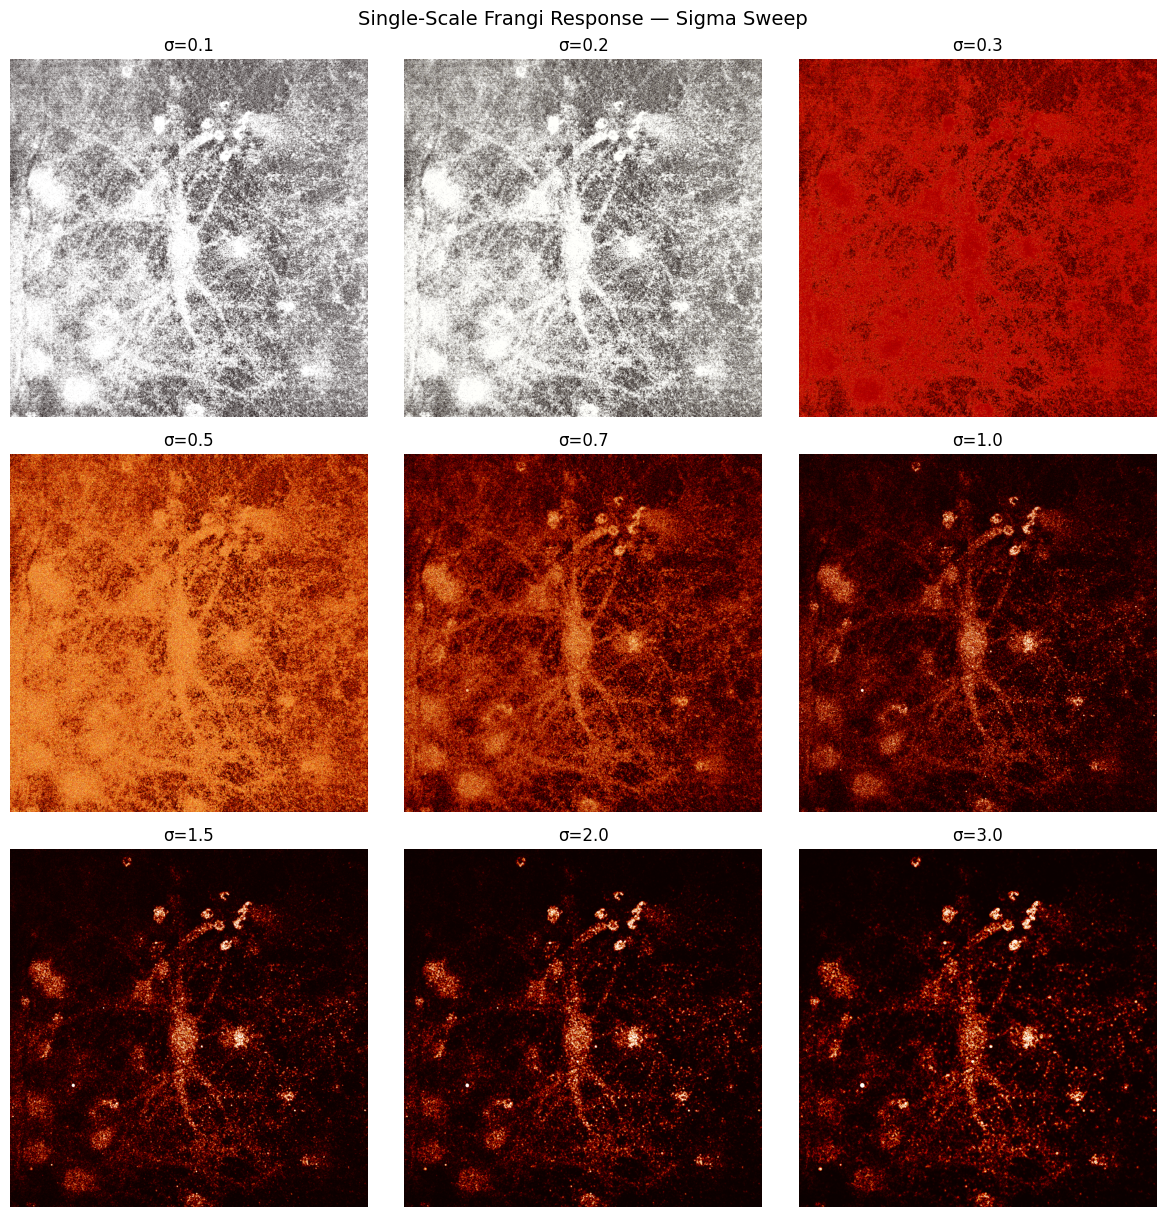

In [34]:
# Visualize: grid of responses
resp_images = [r['response'] for r in sigma_sweep_results]
resp_titles = [f"σ={r['sigma']}" for r in sigma_sweep_results]

show_imgs(resp_images, titles=resp_titles, cmap='hot', max_cols=3,
          figsize=(12, 4 * math.ceil(len(resp_images) / 3)))
plt.suptitle('Single-Scale Frangi Response — Sigma Sweep', y=1.01,
             fontsize=14)
plt.show()
plt.close('all')

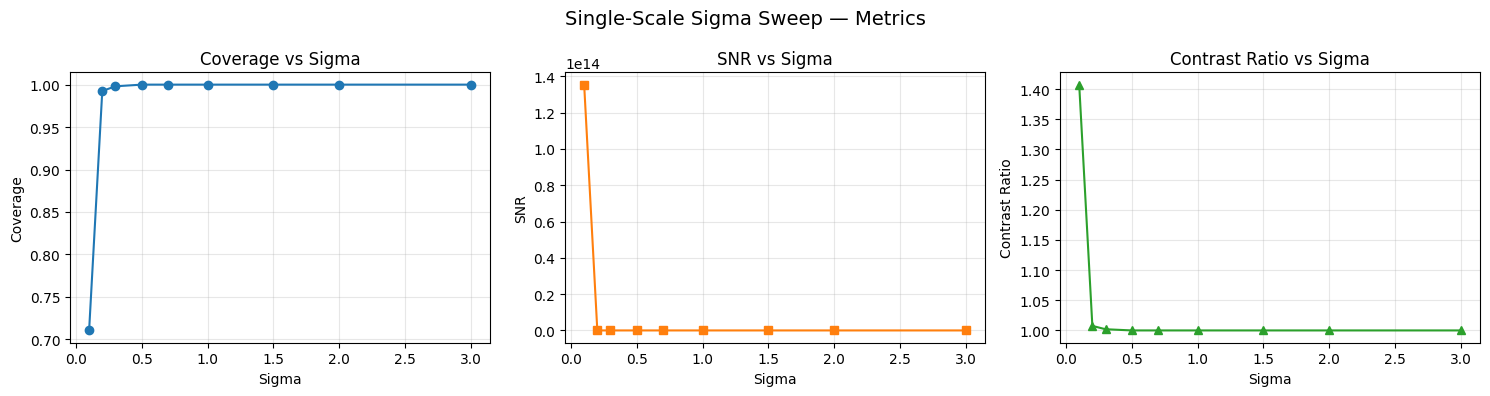

In [29]:
# Plot: metrics vs sigma
sigmas_arr = [r['sigma'] for r in sigma_sweep_results]
coverages  = [r['metrics']['coverage'] for r in sigma_sweep_results]
snrs       = [r['metrics']['snr'] for r in sigma_sweep_results]
contrasts  = [r['metrics']['contrast_ratio'] for r in sigma_sweep_results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(sigmas_arr, coverages, 'o-', color='tab:blue')
axes[0].set_xlabel('Sigma')
axes[0].set_ylabel('Coverage')
axes[0].set_title('Coverage vs Sigma')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sigmas_arr, snrs, 's-', color='tab:orange')
axes[1].set_xlabel('Sigma')
axes[1].set_ylabel('SNR')
axes[1].set_title('SNR vs Sigma')
axes[1].grid(True, alpha=0.3)

axes[2].plot(sigmas_arr, contrasts, '^-', color='tab:green')
axes[2].set_xlabel('Sigma')
axes[2].set_ylabel('Contrast Ratio')
axes[2].set_title('Contrast Ratio vs Sigma')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Single-Scale Sigma Sweep — Metrics', fontsize=14)
plt.tight_layout()
plt.show()
plt.close('all')

---
## Section 6: Multi-Scale Sigma Combination Sweep

In [39]:
multiscale_results = []
fixed_beta = 0.5
fixed_c = 2e6

In [40]:
for combo in tqdm(sigma_combinations, desc='Multi-scale sweep'):
    ms_resp, _ = multiscale_frangi_2d(img_ch0, sigmas=combo, beta=fixed_beta,
                                      c_mode='proportional', c_value=fixed_c)
    metrics = compute_metrics(ms_resp, img_ch0)
    multiscale_results.append({
        'sigmas': combo,
        'response': ms_resp,
        'metrics': metrics,
    })

print(f'Computed {len(multiscale_results)} multi-scale results.')

Multi-scale sweep: 100%|██████████| 4/4 [00:09<00:00,  2.33s/it]

Computed 4 multi-scale results.


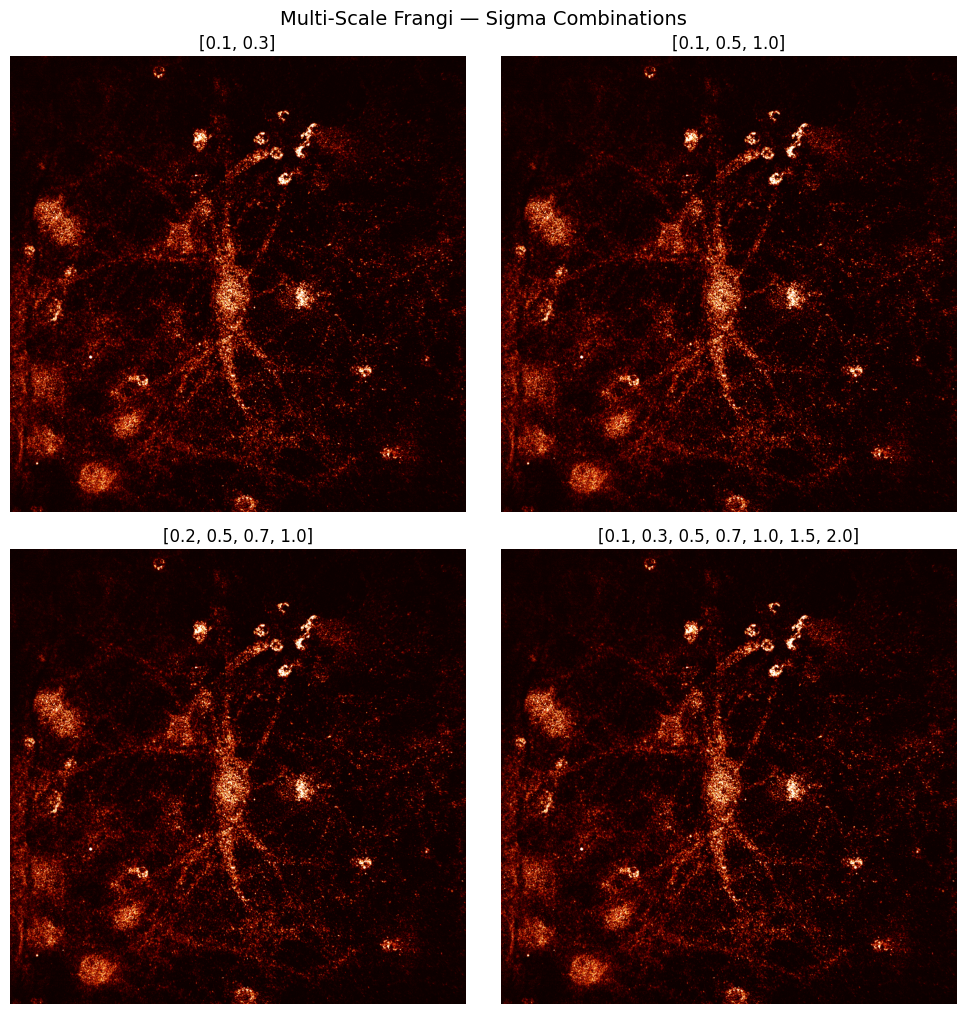

In [41]:
# Side-by-side visualization
ms_images = [r['response'] for r in multiscale_results]
ms_titles = [str(r['sigmas']) for r in multiscale_results]

show_imgs(ms_images, titles=ms_titles, cmap='hot', max_cols=2,
          figsize=(10, 5 * math.ceil(len(ms_images) / 2)))
plt.suptitle('Multi-Scale Frangi — Sigma Combinations', y=1.01, fontsize=14)
plt.show()
plt.close('all')

In [42]:
# Summary table
ms_rows = []
for r in multiscale_results:
    row = {'sigmas': str(r['sigmas'])}
    row.update(r['metrics'])
    ms_rows.append(row)

df_multiscale = pd.DataFrame(ms_rows)
display(df_multiscale)

,sigmas,mean_response,coverage,contrast_ratio,snr,sparsity,dynamic_range
0,"[0.1, 0.3]",1.368415e-05,0.997447,1.002559,0.050547,0.002553,8.764462e+15
1,"[0.1, 0.5, 1.0]",1.364926e-05,1.000000,1.000000,0.050482,0.000000,4.049967e+14
2,"[0.2, 0.5, 0.7, 1.0]",2.255488e-07,1.000000,1.000000,0.022795,0.000000,2.284300e+13
3,"[0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]",1.364926e-05,1.000000,1.000000,0.050482,0.000000,1.087193e+14


---
## Section 7: Beta and C Parameter Sweep

In [43]:
# Fixed sigma for this sweep
sweep_sigma = 0.5

# Pre-compute eigenvalues for the fixed sigma
lam1_sweep, lam2_sweep = compute_hessian_2d(img_ch0, sweep_sigma)

beta_c_results = []

param_grid_bc = generate_param_grid(beta=beta_values, c=c_values_basic)
print(f'Beta x C grid: {len(param_grid_bc)} combinations')

for params in tqdm(param_grid_bc, desc='Beta/C sweep'):
    resp = frangi_filter_2d(lam1_sweep, lam2_sweep,
                            beta=params['beta'], c=params['c'])
    metrics = compute_metrics(resp, img_ch0)
    beta_c_results.append({
        'beta': params['beta'],
        'c': params['c'],
        'response': resp,
        'metrics': metrics,
    })

print(f'Computed {len(beta_c_results)} beta/c results.')

Beta x C grid: 30 combinations


Beta/C sweep: 100%|██████████| 30/30 [00:08<00:00,  3.48it/s]

Computed 30 beta/c results.


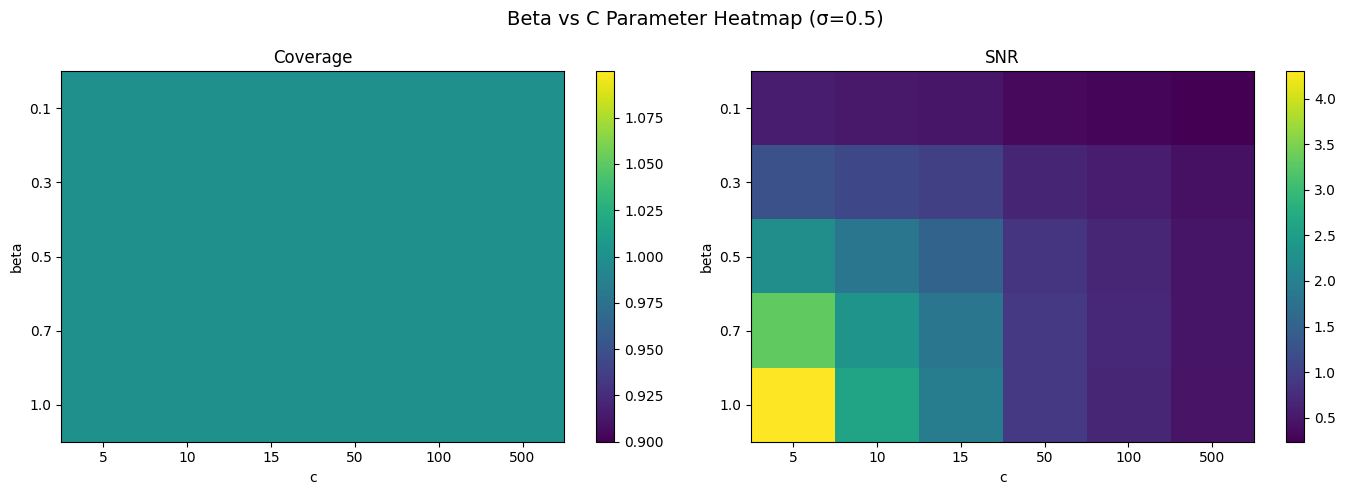

In [44]:
# Build heatmap data: coverage and SNR
coverage_matrix = np.zeros((len(beta_values), len(c_values_basic)))
snr_matrix = np.zeros_like(coverage_matrix)

for r in beta_c_results:
    bi = beta_values.index(r['beta'])
    ci = c_values_basic.index(r['c'])
    coverage_matrix[bi, ci] = r['metrics']['coverage']
    snr_matrix[bi, ci] = r['metrics']['snr']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(coverage_matrix, aspect='auto', cmap='viridis')
axes[0].set_xticks(range(len(c_values_basic)))
axes[0].set_xticklabels([str(c) for c in c_values_basic])
axes[0].set_yticks(range(len(beta_values)))
axes[0].set_yticklabels([str(b) for b in beta_values])
axes[0].set_xlabel('c')
axes[0].set_ylabel('beta')
axes[0].set_title('Coverage')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(snr_matrix, aspect='auto', cmap='viridis')
axes[1].set_xticks(range(len(c_values_basic)))
axes[1].set_xticklabels([str(c) for c in c_values_basic])
axes[1].set_yticks(range(len(beta_values)))
axes[1].set_yticklabels([str(b) for b in beta_values])
axes[1].set_xlabel('c')
axes[1].set_ylabel('beta')
axes[1].set_title('SNR')
plt.colorbar(im1, ax=axes[1])

plt.suptitle(f'Beta vs C Parameter Heatmap (σ={sweep_sigma})', fontsize=14)
plt.tight_layout()
plt.show()
plt.close('all')

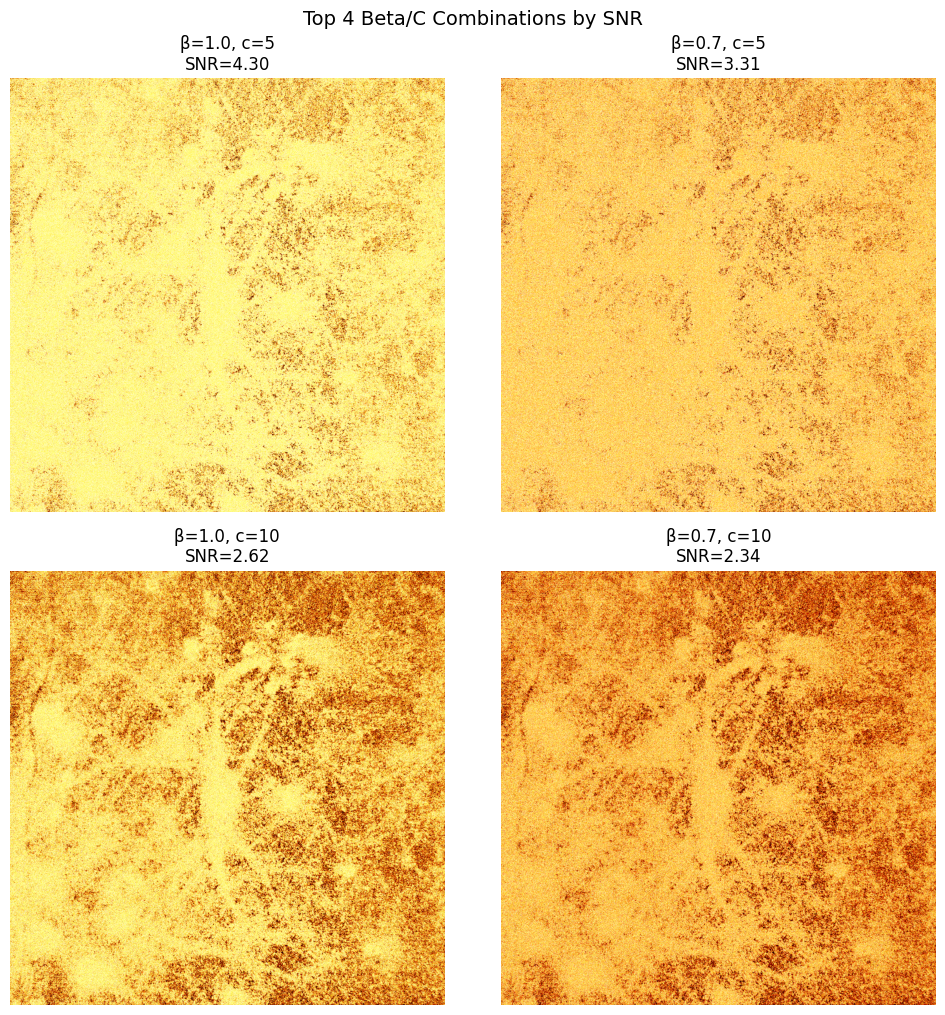

In [46]:
# Show best 4 parameter combinations (by SNR)
sorted_bc = sorted(beta_c_results, key=lambda r: r['metrics']['snr'],
                   reverse=True)
best4 = sorted_bc[:4]

best4_imgs = [r['response'] for r in best4]
best4_titles = [f"β={r['beta']}, c={r['c']}\nSNR={r['metrics']['snr']:.2f}"
                for r in best4]

show_imgs(best4_imgs, titles=best4_titles, cmap='hot', max_cols=2,
          figsize=(10, 10))
plt.suptitle('Top 4 Beta/C Combinations by SNR', y=1.01, fontsize=14)
plt.show()
plt.close('all')

---
## Section 8: Adaptive Pipeline Parameter Sweep

In [47]:
# Sweep beta, c (adaptive), and soma_percentile
adaptive_beta_values = [0.3, 0.5, 0.8, 1.0]
adaptive_c_values = [1e5, 1e6, 2e6, 1e7]
adaptive_soma_pcts = [93, 95, 97, 99]

# Select a smaller grid to keep runtime manageable
adaptive_grid = generate_param_grid(
    beta=adaptive_beta_values,
    c=adaptive_c_values,
    soma_percentile=adaptive_soma_pcts,
)

print(f'Adaptive grid: {len(adaptive_grid)} combinations')

adaptive_results = []

for params in tqdm(adaptive_grid, desc='Adaptive sweep'):
    resp, fg, smap = adaptive_frangi_ddeep3m(
        img_ch0, beta=params['beta'], c=params['c'],
        soma_percentile=params['soma_percentile'])
    metrics = compute_metrics(resp, img_ch0)
    adaptive_results.append({
        'beta': params['beta'],
        'c': params['c'],
        'soma_percentile': params['soma_percentile'],
        'response': resp,
        'fg_mask': fg,
        'sigma_map': smap,
        'metrics': metrics,
    })

print(f'Computed {len(adaptive_results)} adaptive results.')

Adaptive grid: 64 combinations


Adaptive sweep: 100%|██████████| 64/64 [07:46<00:00,  7.29s/it]

Computed 64 adaptive results.


In [ ]:
# Compare adaptive vs. fixed-scale: pick the best adaptive result by SNR
best_adaptive = max(adaptive_results, key=lambda r: r['metrics']['snr'])
best_fixed = max(sigma_sweep_results, key=lambda r: r['metrics']['snr'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Adaptive sigma map
im0 = axes[0].imshow(best_adaptive['sigma_map'], cmap='jet')
axes[0].set_title('Adaptive Sigma Map')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Best fixed result
axes[1].imshow(best_fixed['response'], cmap='hot', vmin=0,
               vmax=np.percentile(best_fixed['response'], 99.5))
axes[1].set_title(f"Fixed σ={best_fixed['sigma']}\n"
                  f"SNR={best_fixed['metrics']['snr']:.2f}")
axes[1].axis('off')

# Best adaptive result
axes[2].imshow(best_adaptive['response'], cmap='hot', vmin=0,
               vmax=np.percentile(best_adaptive['response'], 99.5))
axes[2].set_title(f"Adaptive β={best_adaptive['beta']}, "
                  f"c={best_adaptive['c']:.0e}\n"
                  f"soma_pct={best_adaptive['soma_percentile']}, "
                  f"SNR={best_adaptive['metrics']['snr']:.2f}")
axes[2].axis('off')

plt.suptitle('Fixed vs Adaptive Frangi', fontsize=14)
plt.tight_layout()
plt.show()
plt.close('all')

In [ ]:
# Summary table of adaptive results
adaptive_rows = []
for r in adaptive_results:
    row = {
        'beta': r['beta'],
        'c': r['c'],
        'soma_percentile': r['soma_percentile'],
    }
    row.update(r['metrics'])
    adaptive_rows.append(row)

df_adaptive = pd.DataFrame(adaptive_rows)
df_adaptive_sorted = df_adaptive.sort_values('snr', ascending=False)
display(df_adaptive_sorted.head(15))

---
## Section 9: Threshold Sensitivity Analysis

For the best Frangi response (from Section 5), sweep percentile thresholds.

In [ ]:
# Use the best fixed-scale response
best_response = best_fixed['response']

threshold_results = []

for pct in tqdm(percentile_thresholds, desc='Threshold sweep'):
    nonzero = best_response[best_response > 0]
    if len(nonzero) == 0:
        thr = 0
    else:
        thr = np.percentile(nonzero, pct)
    mask = best_response > thr

    mask_metrics = compute_mask_metrics(mask, best_response)

    threshold_results.append({
        'percentile': pct,
        'threshold': thr,
        'mask': mask,
        'mask_metrics': mask_metrics,
    })

print(f'Computed {len(threshold_results)} threshold results.')

In [ ]:
# Visualize masks at different thresholds
thr_images = [r['mask'].astype(float) for r in threshold_results]
thr_titles = [f"Pct={r['percentile']}, Coverage={r['mask_metrics']['mask_coverage']:.4f}"
              for r in threshold_results]

show_imgs(thr_images, titles=thr_titles, cmap='gray', max_cols=3,
          figsize=(12, 4 * math.ceil(len(thr_images) / 3)))
plt.suptitle(f'Threshold Sensitivity (σ={best_fixed["sigma"]})', y=1.01,
             fontsize=14)
plt.show()
plt.close('all')

In [ ]:
# Plot coverage vs. threshold
pcts = [r['percentile'] for r in threshold_results]
covs = [r['mask_metrics']['mask_coverage'] for r in threshold_results]
ccs  = [r['mask_metrics']['connected_components'] for r in threshold_results]

fig, ax1 = plt.subplots(figsize=(8, 5))

color1 = 'tab:blue'
ax1.plot(pcts, covs, 'o-', color=color1, label='Coverage')
ax1.set_xlabel('Percentile Threshold')
ax1.set_ylabel('Mask Coverage', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.plot(pcts, ccs, 's-', color=color2, label='Components')
ax2.set_ylabel('Connected Components', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Threshold Sensitivity: Coverage & Connected Components')
fig.tight_layout()
plt.show()
plt.close('all')

In [ ]:
# Overlay masks at different thresholds on original
n_thr = len(threshold_results)
fig, axes = plt.subplots(1, n_thr, figsize=(5 * n_thr, 5))
if n_thr == 1:
    axes = [axes]

for i, r in enumerate(threshold_results):
    axes[i].imshow(img_ch0, cmap='gray', vmin=0,
                   vmax=np.percentile(img_ch0, 99.5))
    axes[i].imshow(r['mask'].astype(float),
                   cmap=_black_to((1, 0, 0)), alpha=0.4, vmin=0, vmax=1)
    axes[i].set_title(f"Pct={r['percentile']}")
    axes[i].axis('off')

plt.suptitle('Threshold Overlays on Original', fontsize=14)
plt.tight_layout()
plt.show()
plt.close('all')

---
## Section 10: Cross-Channel Comparison

Run the best parameter set on all channels and compare.

In [ ]:
best_sigma = best_fixed['sigma']
print(f'Best fixed-scale parameters: σ={best_sigma}, β={fixed_beta}, c={fixed_c}')

channel_results = []

for ch in tqdm(channels, desc='Cross-channel sweep'):
    img_ch = data_z_sliced[ch].astype(np.float64)
    lam1, lam2 = compute_hessian_2d(img_ch, best_sigma)
    resp = frangi_filter_2d(lam1, lam2, beta=fixed_beta, c=fixed_c)
    metrics = compute_metrics(resp, img_ch)
    channel_results.append({
        'channel': ch,
        'response': resp,
        'metrics': metrics,
    })

print(f'Computed results for {len(channel_results)} channels.')

In [ ]:
# Side-by-side comparison
ch_imgs = [data_z_sliced[ch] for ch in channels] + \
          [r['response'] for r in channel_results]
ch_titles = [f'Ch {ch} — Original' for ch in channels] + \
            [f'Ch {r["channel"]} — Frangi' for r in channel_results]

ch_cmaps = [DEFAULT_CHANNEL_CMAPS[ch % len(DEFAULT_CHANNEL_CMAPS)]
            for ch in channels] + ['hot'] * len(channels)

n = len(ch_imgs)
cols = min(3, n)
rows = math.ceil(n / cols)

fig, axs = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5),
                        squeeze=False)
axs_flat = axs.ravel()

for i, ax in enumerate(axs_flat):
    if i < n:
        im = np.asarray(ch_imgs[i])
        ax.imshow(im, cmap=ch_cmaps[i], vmin=0,
                  vmax=np.percentile(im, 99.5))
        ax.set_title(ch_titles[i])
    ax.axis('off')

plt.suptitle(f'Cross-Channel Comparison (σ={best_sigma})', fontsize=14)
plt.tight_layout()
plt.show()
plt.close('all')

In [ ]:
# Metrics table per channel
ch_rows = []
for r in channel_results:
    row = {'channel': r['channel']}
    row.update(r['metrics'])
    ch_rows.append(row)

df_channels = pd.DataFrame(ch_rows)
display(df_channels)

---
## Section 11: Results Summary

In [ ]:
# Aggregate all results into a final summary DataFrame
all_rows = []

# --- Single-scale sigma sweep ---
for r in sigma_sweep_results:
    row = {
        'experiment': 'single_scale_sigma',
        'sigma': r['sigma'],
        'beta': fixed_beta,
        'c': fixed_c,
        'channel': 0,
        'c_mode': 'fixed',
        'soma_percentile': None,
        'sigmas_combo': str(r['sigma']),
    }
    row.update(r['metrics'])
    all_rows.append(row)

# --- Multi-scale sigma combinations ---
for r in multiscale_results:
    row = {
        'experiment': 'multiscale_sigma',
        'sigma': None,
        'beta': 0.5,
        'c': None,
        'channel': 0,
        'c_mode': 'proportional',
        'soma_percentile': None,
        'sigmas_combo': str(r['sigmas']),
    }
    row.update(r['metrics'])
    all_rows.append(row)

# --- Beta/C sweep ---
for r in beta_c_results:
    row = {
        'experiment': 'beta_c_sweep',
        'sigma': sweep_sigma,
        'beta': r['beta'],
        'c': r['c'],
        'channel': 0,
        'c_mode': 'fixed',
        'soma_percentile': None,
        'sigmas_combo': str(sweep_sigma),
    }
    row.update(r['metrics'])
    all_rows.append(row)

# --- Adaptive sweep ---
for r in adaptive_results:
    row = {
        'experiment': 'adaptive_ddeep3m',
        'sigma': None,
        'beta': r['beta'],
        'c': r['c'],
        'channel': 0,
        'c_mode': 'adaptive',
        'soma_percentile': r['soma_percentile'],
        'sigmas_combo': 'adaptive',
    }
    row.update(r['metrics'])
    all_rows.append(row)

# --- Cross-channel ---
for r in channel_results:
    row = {
        'experiment': 'cross_channel',
        'sigma': best_sigma,
        'beta': fixed_beta,
        'c': fixed_c,
        'channel': r['channel'],
        'c_mode': 'fixed',
        'soma_percentile': None,
        'sigmas_combo': str(best_sigma),
    }
    row.update(r['metrics'])
    all_rows.append(row)

df_all = pd.DataFrame(all_rows)
print(f'Total experiments: {len(df_all)}')
display(df_all.head(10))

In [ ]:
# Identify optimal parameter set(s) per experiment type
print('\n=== Optimal Parameters per Experiment (by SNR) ===\n')

for exp_name in df_all['experiment'].unique():
    subset = df_all[df_all['experiment'] == exp_name]
    best_idx = subset['snr'].idxmax()
    best_row = subset.loc[best_idx]
    print(f'--- {exp_name} ---')
    display(pd.DataFrame([best_row]))
    print()

In [48]:
# Save summary to CSV
#csv_path = 'parameter_sweep_results.csv'
#df_all.to_csv(csv_path, index=False)
#print(f'Results saved to notebooks/{csv_path}')